In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import time
import pickle
import json
from datetime import datetime
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from scipy.optimize import differential_evolution, dual_annealing

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'KaiTi']
plt.rcParams['axes.unicode_minus'] = False


# 设置随机种子
np.random.seed(42)
torch.manual_seed(42)

In [2]:
output_dirs = ['dl_models', 'dl_plots', 'dl_csv', 'dl_reports', 'dl_predictions']
for dir_name in output_dirs:
    os.makedirs(f'stk_DL/{dir_name}', exist_ok=True)

In [5]:
device = 'cpu'
print(f"使用设备: {device}")
print(f"PyTorch版本: {torch.__version__}")

使用设备: cpu
PyTorch版本: 2.13.0+cpu


In [3]:
# ==================== 数据预处理 ====================
def load_and_preprocess_optimized(file_path):
    """优化数据预处理"""
    print("加载数据...")
    df = pd.read_csv(file_path)
    print(f"原始数据形状: {df.shape}")
    
    # 转换日期
    df['trade_date'] = pd.to_datetime(df['trade_date'])
    df = df.sort_values(['ts_code', 'trade_date']).reset_index(drop=True)
    
    # 1. 处理缺失值 - 使用前向填充
    df = df.groupby('ts_code').apply(lambda x: x.ffill().bfill())
    df = df.fillna(0)
    df = df.replace([np.inf, -np.inf], 0)
    
    # 2. 计算未来收益率（使用对数收益率更稳定）
    print("计算对数收益率...")
    df['log_return_5d'] = df.groupby('ts_code')['close'].transform(
        lambda x: np.log(x.shift(-5) / x)
    )
    df['log_return_10d'] = df.groupby('ts_code')['close'].transform(
        lambda x: np.log(x.shift(-10) / x)
    )
    df['log_return_20d'] = df.groupby('ts_code')['close'].transform(
        lambda x: np.log(x.shift(-20) / x)
    )
    
    # 3. 填充未来收益率
    for col in ['log_return_5d', 'log_return_10d', 'log_return_20d']:
        df[col] = df.groupby('ts_code')[col].transform(lambda x: x.fillna(0))
    
    # 4. 特征列
    exclude_cols = ['ts_code', 'trade_date', 'year_month', 
                    'future_5d_return', 'future_10d_return', 'future_20d_return',
                    'log_return_5d', 'log_return_10d', 'log_return_20d']
    feature_cols = [col for col in df.columns if col not in exclude_cols]
    
    # 5. 剔除异常值（3倍标准差）
    print("剔除异常值...")
    for col in feature_cols:
        if col in df.columns:
            mean_val = df[col].mean()
            std_val = df[col].std()
            df[col] = df[col].clip(mean_val - 3*std_val, mean_val + 3*std_val)
    
    print(f"特征数量: {len(feature_cols)}")
    print(f"日期范围: {df['trade_date'].min()} 到 {df['trade_date'].max()}")
    
    return df, feature_cols

df, feature_cols = load_and_preprocess_optimized('../extracted_data/selected_factors_with_data1.csv')
print("="*60)

加载数据...
原始数据形状: (23979, 36)
计算对数收益率...
剔除异常值...
特征数量: 32
日期范围: 2024-01-02 00:00:00 到 2025-01-10 00:00:00


In [4]:
# ==================== 时序数据构建 ====================
def create_sequences_optimized(df, feature_cols, target_col, sequence_length=20, 
                               train_ratio=0.6, val_ratio=0.2):
    """优化时序数据构建 - 使用滚动标准化"""
    print(f"\n创建时序序列 (序列长度={sequence_length})...")
    
    all_X, all_y, all_dates, all_codes = [], [], [], []
    
    # 全局标准化器（用训练集拟合）
    scaler = StandardScaler()
    
    # 获取所有股票
    stock_groups = df.groupby('ts_code')
    print(f"共有 {len(stock_groups)} 只股票")
    
    # 先收集所有数据用于全局标准化
    all_raw_data = []
    for stock_code, stock_data in stock_groups:
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        if len(stock_data) > sequence_length:
            all_raw_data.append(stock_data[feature_cols].values)
    
    if all_raw_data:
        all_raw = np.vstack(all_raw_data)
        scaler.fit(all_raw)
        print(f"全局标准化拟合完成，均值范围: {scaler.mean_.min():.4f} ~ {scaler.mean_.max():.4f}")
    
    # 创建序列
    processed_count = 0
    for stock_code, stock_data in stock_groups:
        stock_data = stock_data.sort_values('trade_date').reset_index(drop=True)
        
        if len(stock_data) <= sequence_length + 5:
            continue
        
        # 标准化
        X_raw = stock_data[feature_cols].values
        X_scaled = scaler.transform(X_raw)
        y_raw = stock_data[target_col].values
        
        # 创建滑动窗口
        for i in range(sequence_length, len(X_raw) - 1):
            window = X_scaled[i - sequence_length:i]
            label = y_raw[i]  # 使用当天的未来收益率
            
            all_X.append(window)
            all_y.append(label)
            all_dates.append(stock_data['trade_date'].iloc[i])
            all_codes.append(stock_code)
        
        processed_count += 1
        if processed_count % 50 == 0:
            print(f"  已处理 {processed_count} 只股票, 累计样本 {len(all_X)}...")
    
    X = np.array(all_X, dtype=np.float32)
    y = np.array(all_y, dtype=np.float32)
    dates = np.array(all_dates)
    codes = np.array(all_codes)
    
    print(f"\n总样本数: {len(X)}")
    print(f"序列形状: {X.shape}")
    
    # 按时间划分
    unique_dates = sorted(np.unique(dates))
    n_dates = len(unique_dates)
    train_cutoff = unique_dates[int(n_dates * train_ratio)]
    val_cutoff = unique_dates[int(n_dates * (train_ratio + val_ratio))]
    
    train_mask = dates <= train_cutoff
    val_mask = (dates > train_cutoff) & (dates <= val_cutoff)
    test_mask = dates > val_cutoff
    
    X_train, y_train = X[train_mask], y[train_mask]
    X_val, y_val = X[val_mask], y[val_mask]
    X_test, y_test = X[test_mask], y[test_mask]
    
    dates_train, dates_val, dates_test = dates[train_mask], dates[val_mask], dates[test_mask]
    codes_train, codes_val, codes_test = codes[train_mask], codes[val_mask], codes[test_mask]
    
    print(f"\n数据划分:")
    print(f"  训练集: {len(X_train)} 样本, 日期: {dates_train.min()} 到 {dates_train.max()}")
    print(f"  验证集: {len(X_val)} 样本, 日期: {dates_val.min()} 到 {dates_val.max()}")
    print(f"  测试集: {len(X_test)} 样本, 日期: {dates_test.min()} 到 {dates_test.max()}")
    
    return (X_train, y_train, dates_train, codes_train,
            X_val, y_val, dates_val, codes_val,
            X_test, y_test, dates_test, codes_test, scaler)

# 使用优化参数
sequence_length = 20  # 缩短序列长度，减少过拟合
target_col = 'log_return_5d'  # 使用对数收益率

(X_train, y_train, dates_train, codes_train,
 X_val, y_val, dates_val, codes_val,
 X_test, y_test, dates_test, codes_test, scaler) = create_sequences_optimized(
    df, feature_cols, target_col, sequence_length=sequence_length
)

print("="*60)


创建时序序列 (序列长度=20)...
共有 100 只股票
全局标准化拟合完成，均值范围: -0.0950 ~ 221970.3948
  已处理 50 只股票, 累计样本 10803...
  已处理 100 只股票, 累计样本 21879...

总样本数: 21879
序列形状: (21879, 20, 32)

数据划分:
  训练集: 13225 样本, 日期: 2024-01-30 00:00:00 到 2024-08-23 00:00:00
  验证集: 4292 样本, 日期: 2024-08-26 00:00:00 到 2024-11-06 00:00:00
  测试集: 4362 样本, 日期: 2024-11-07 00:00:00 到 2025-01-09 00:00:00


In [5]:
# ==================== 优化模型架构 ====================
class ImprovedLSTM(nn.Module):
    """改进的LSTM模型 - 添加残差连接和层归一化"""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.3):
        super(ImprovedLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0,
                            bidirectional=False)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.layer_norm(out[:, -1, :])
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

class ImprovedGRU(nn.Module):
    """改进的GRU模型"""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.3):
        super(ImprovedGRU, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, 
                          batch_first=True, dropout=dropout if num_layers > 1 else 0,
                          bidirectional=False)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out, _ = self.gru(x)
        out = self.layer_norm(out[:, -1, :])
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

class AttentionLSTM(nn.Module):
    """带注意力机制的LSTM"""
    def __init__(self, input_dim, hidden_dim=64, num_layers=2, output_dim=1, dropout=0.3):
        super(AttentionLSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, 
                            batch_first=True, dropout=dropout if num_layers > 1 else 0)
        self.attention = nn.MultiheadAttention(hidden_dim, num_heads=4, batch_first=True)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, hidden_dim // 2)
        self.fc2 = nn.Linear(hidden_dim // 2, output_dim)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        attn_out, _ = self.attention(lstm_out, lstm_out, lstm_out)
        out = self.layer_norm(attn_out[:, -1, :])
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

print("优化模型定义完成！")
print("="*60)

优化模型定义完成！


In [6]:
# ==================== 训练函数 ====================
def train_optimized(model, train_loader, val_loader, epochs=80, lr=0.001, 
                    patience=20, device='cpu', model_name='Model'):
    """优化训练函数 - 添加学习率调度和梯度裁剪"""
    print(f"\n{'='*60}")
    print(f"训练 {model_name}")
    print(f"{'='*60}")
    
    model = model.to(device)
    criterion = nn.HuberLoss()  # 使用Huber损失，对异常值更鲁棒
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        # 训练
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        # 验证
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        scheduler.step()
        
        # 早停
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_state)
    print(f"\n{model_name} 训练完成! 最佳验证损失: {best_val_loss:.6f}")
    
    return model, train_losses, val_losses

print("优化训练函数准备就绪！")
print("="*60)

优化训练函数准备就绪！


In [7]:
# ==================== 创建DataLoader ====================
class TimeSeriesDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
        
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.FloatTensor([self.labels[idx]])

batch_size = 128
train_dataset = TimeSeriesDataset(X_train, y_train)
val_dataset = TimeSeriesDataset(X_val, y_val)
test_dataset = TimeSeriesDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"DataLoader创建完成:")
print(f"  训练集: {len(train_loader)} 批次")
print(f"  验证集: {len(val_loader)} 批次")
print(f"  测试集: {len(test_loader)} 批次")
print("="*60)

DataLoader创建完成:
  训练集: 104 批次
  验证集: 34 批次
  测试集: 35 批次


使用设备: cpu
PyTorch版本: 2.13.0+cpu

开始训练优化模型

训练优化LSTM...

训练 LSTM_Improved
Epoch 10/80, Train Loss: 0.002275, Val Loss: 0.006084
Epoch 20/80, Train Loss: 0.001741, Val Loss: 0.006289
Epoch 30/80, Train Loss: 0.001383, Val Loss: 0.006374
Early stopping at epoch 34

LSTM_Improved 训练完成! 最佳验证损失: 0.005925
LSTM训练完成，最佳验证损失: 0.005925

训练优化GRU...

训练 GRU_Improved
Epoch 10/80, Train Loss: 0.002235, Val Loss: 0.005929
Epoch 20/80, Train Loss: 0.001837, Val Loss: 0.006426
Early stopping at epoch 21

GRU_Improved 训练完成! 最佳验证损失: 0.005569
GRU训练完成，最佳验证损失: 0.005569

训练Attention LSTM...

训练 AttentionLSTM
Epoch 10/80, Train Loss: 0.002180, Val Loss: 0.005669
Epoch 20/80, Train Loss: 0.001638, Val Loss: 0.005984
Early stopping at epoch 24

AttentionLSTM 训练完成! 最佳验证损失: 0.005352
AttentionLSTM训练完成，最佳验证损失: 0.005352
LSTM 模型已保存
GRU 模型已保存
AttentionLSTM 模型已保存


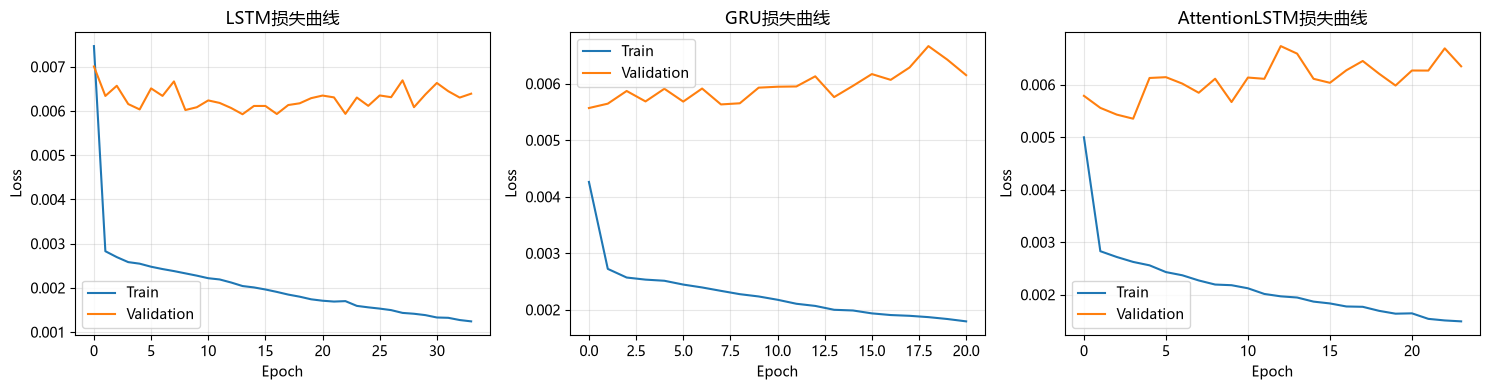


所有模型训练完成！


In [11]:
# ==================== 设置设备 ====================
import torch
device = 'cpu'  # 强制使用CPU
print(f"使用设备: {device}")
print(f"PyTorch版本: {torch.__version__}")

# ==================== 训练模型 ====================
print("\n" + "="*60)
print("开始训练优化模型")
print("="*60)

input_dim = X_train.shape[2]
hidden_dim = 64
num_layers = 2
dropout = 0.3
epochs = 80
lr = 0.001

models = {}

# 1. 训练优化LSTM
print("\n训练优化LSTM...")
lstm_model = ImprovedLSTM(input_dim, hidden_dim, num_layers, dropout=dropout)
lstm_model, lstm_train_loss, lstm_val_loss = train_optimized(
    lstm_model, train_loader, val_loader, epochs, lr, 
    patience=20, device=device, model_name='LSTM_Improved'
)
models['LSTM'] = lstm_model
print(f"LSTM训练完成，最佳验证损失: {min(lstm_val_loss):.6f}")

# 2. 训练优化GRU
print("\n训练优化GRU...")
gru_model = ImprovedGRU(input_dim, hidden_dim, num_layers, dropout=dropout)
gru_model, gru_train_loss, gru_val_loss = train_optimized(
    gru_model, train_loader, val_loader, epochs, lr, 
    patience=20, device=device, model_name='GRU_Improved'
)
models['GRU'] = gru_model
print(f"GRU训练完成，最佳验证损失: {min(gru_val_loss):.6f}")

# 3. 训练Attention LSTM
print("\n训练Attention LSTM...")
attn_model = AttentionLSTM(input_dim, hidden_dim, num_layers, dropout=dropout)
attn_model, attn_train_loss, attn_val_loss = train_optimized(
    attn_model, train_loader, val_loader, epochs, lr, 
    patience=20, device=device, model_name='AttentionLSTM'
)
models['AttentionLSTM'] = attn_model
print(f"AttentionLSTM训练完成，最佳验证损失: {min(attn_val_loss):.6f}")

# 保存模型
for name, model in models.items():
    torch.save(model.state_dict(), f'stk_DL/dl_models/{name}_model.pth')
    print(f"{name} 模型已保存")

# 绘制训练损失曲线
try:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    axes[0].plot(lstm_train_loss, label='Train')
    axes[0].plot(lstm_val_loss, label='Validation')
    axes[0].set_title('LSTM损失曲线')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(gru_train_loss, label='Train')
    axes[1].plot(gru_val_loss, label='Validation')
    axes[1].set_title('GRU损失曲线')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    axes[2].plot(attn_train_loss, label='Train')
    axes[2].plot(attn_val_loss, label='Validation')
    axes[2].set_title('AttentionLSTM损失曲线')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('stk_DL/dl_plots/training_loss.png', dpi=300, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"绘制损失曲线时出错: {e}")

print("\n所有模型训练完成！")
print("="*60)

In [12]:
# ==================== 重新评估和预测 ====================
def evaluate_optimized(model, data_loader, device='cpu'):
    """评估模型"""
    model.eval()
    preds, actuals = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            preds.extend(y_pred.cpu().numpy().flatten())
            actuals.extend(y_batch.numpy().flatten())
    
    preds = np.array(preds)
    actuals = np.array(actuals)
    
    # 计算方向准确率
    direction_acc = accuracy_score((actuals > 0).astype(int), (preds > 0).astype(int))
    
    return {
        'predictions': preds,
        'actuals': actuals,
        'mse': mean_squared_error(actuals, preds),
        'mae': mean_absolute_error(actuals, preds),
        'direction_acc': direction_acc
    }

print("评估函数准备就绪！")

# ==================== 评估所有模型 ====================
print("\n" + "="*60)
print("模型评估")
print("="*60)

# 获取测试集实际值
actuals = []
with torch.no_grad():
    for _, y_batch in test_loader:
        actuals.extend(y_batch.numpy().flatten())
actuals = np.array(actuals)

results = {}
for name, model in models.items():
    result = evaluate_optimized(model, test_loader, device)
    results[name] = result
    print(f"\n{name}:")
    print(f"  MSE: {result['mse']:.6f}")
    print(f"  MAE: {result['mae']:.6f}")
    print(f"  方向准确率: {result['direction_acc']:.4f}")

# 保存评估结果
results_df = pd.DataFrame({
    'Model': list(results.keys()),
    'MSE': [results[name]['mse'] for name in results],
    'MAE': [results[name]['mae'] for name in results],
    'Direction_Accuracy': [results[name]['direction_acc'] for name in results]
})
results_df.to_csv('stk_DL/dl_csv/model_evaluation.csv', index=False)
print("\n评估结果已保存")

print("="*60)

评估函数准备就绪！

模型评估

LSTM:
  MSE: 0.004849
  MAE: 0.050330
  方向准确率: 0.5908

GRU:
  MSE: 0.004384
  MAE: 0.047095
  方向准确率: 0.4161

AttentionLSTM:
  MSE: 0.004320
  MAE: 0.047447
  方向准确率: 0.4817

评估结果已保存


In [13]:
# ==================== 模型集成 ====================
print("\n" + "="*60)
print("模型集成")
print("="*60)

# 获取所有模型预测
all_predictions = []
model_names = list(models.keys())
for name in model_names:
    result = evaluate_optimized(models[name], test_loader, device)
    all_predictions.append(result['predictions'])

# 1. 等权重集成
ensemble_pred_equal = np.mean(all_predictions, axis=0)
ensemble_acc_equal = accuracy_score((actuals > 0).astype(int), (ensemble_pred_equal > 0).astype(int))
print(f"等权重集成 - 方向准确率: {ensemble_acc_equal:.4f}")

# 2. 基于验证集性能的动态权重
print("\n计算动态权重...")
val_weights = []
for name in model_names:
    val_result = evaluate_optimized(models[name], val_loader, device)
    # 使用方向准确率作为权重
    val_weights.append(max(0.1, val_result['direction_acc']))

val_weights = np.array(val_weights) / sum(val_weights)
print(f"动态权重: {dict(zip(model_names, val_weights))}")

ensemble_pred_weighted = np.zeros_like(all_predictions[0])
for i, pred in enumerate(all_predictions):
    ensemble_pred_weighted += val_weights[i] * pred

ensemble_acc_weighted = accuracy_score((actuals > 0).astype(int), (ensemble_pred_weighted > 0).astype(int))
print(f"动态权重集成 - 方向准确率: {ensemble_acc_weighted:.4f}")

# 3. 投票集成（只取符号）
sign_predictions = np.sign(np.array(all_predictions))
ensemble_pred_vote = np.sum(sign_predictions, axis=0)
ensemble_pred_vote = (ensemble_pred_vote > 0).astype(int) * 2 - 1
ensemble_acc_vote = accuracy_score((actuals > 0).astype(int), (ensemble_pred_vote > 0).astype(int))
print(f"投票集成 - 方向准确率: {ensemble_acc_vote:.4f}")

# 选择最佳集成方法
ensemble_accuracies = {
    'equal': ensemble_acc_equal,
    'weighted': ensemble_acc_weighted,
    'vote': ensemble_acc_vote
}
best_method = max(ensemble_accuracies, key=ensemble_accuracies.get)
print(f"\n最佳集成方法: {best_method} (准确率: {ensemble_accuracies[best_method]:.4f})")

if best_method == 'equal':
    final_predictions = ensemble_pred_equal
elif best_method == 'weighted':
    final_predictions = ensemble_pred_weighted
else:
    final_predictions = ensemble_pred_vote

# 保存预测结果
predictions_df = pd.DataFrame({
    'date': dates_test,
    'code': codes_test,
    'actual': actuals,
    'final_prediction': final_predictions
})
predictions_df.to_csv('stk_DL/dl_predictions/final_predictions.csv', index=False)
print("预测结果已保存")

print("="*60)


模型集成
等权重集成 - 方向准确率: 0.5511

计算动态权重...
动态权重: {'LSTM': np.float64(0.30891313589343916), 'GRU': np.float64(0.34051296584951113), 'AttentionLSTM': np.float64(0.35057389825704977)}
动态权重集成 - 方向准确率: 0.5463
投票集成 - 方向准确率: 0.5046

最佳集成方法: equal (准确率: 0.5511)
预测结果已保存



执行优化回测

优化回测
选股数量: Top 30
交易成本: 0.10%
止损线: -5.00%
回测数据: 4362 条记录
日期范围: 2024-11-07 00:00:00 到 2025-01-09 00:00:00

回测结果:
  总收益率: -36.51%
  年化收益率: -92.15%
  年化波动率: 41.57%
  夏普比率: -2.2165
  最大回撤: -39.76%
  IC: -0.0312
  胜率: 31.11%

回测结果已保存


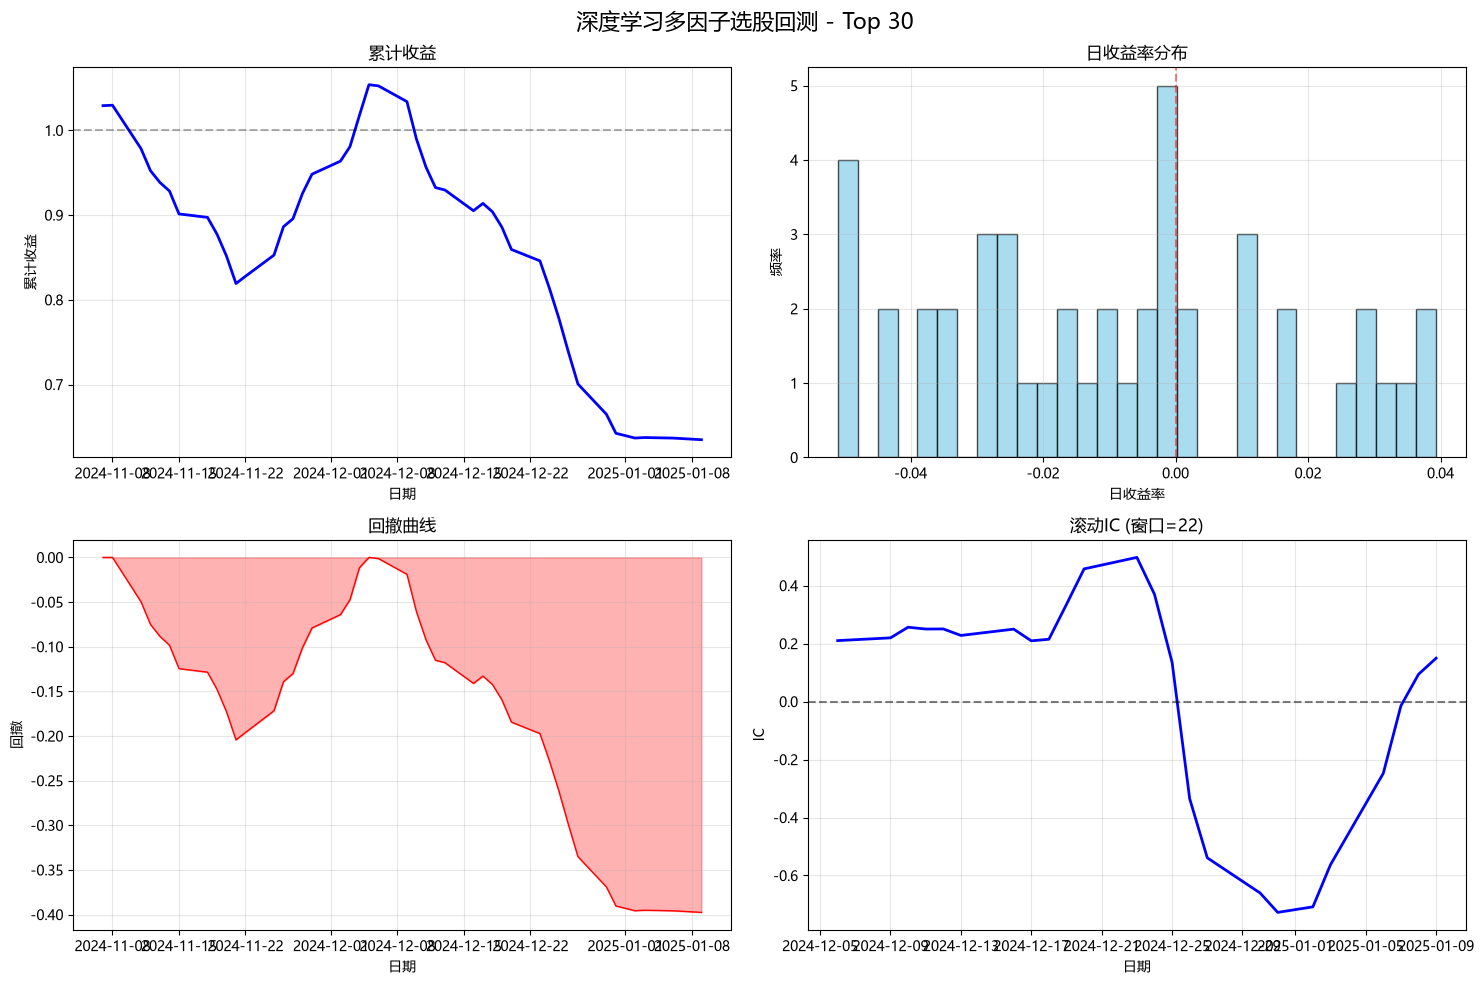


回测结果汇总
  总收益率: -36.51%
  年化收益率: -92.15%
  夏普比率: -2.2165
  最大回撤: -39.76%
  IC: -0.0312
  胜率: 31.11%


In [14]:
# ==================== 回测 ====================
def backtest_optimized(predictions, actuals, dates, codes, top_n=30, 
                       transaction_cost=0.001, stop_loss=-0.05):
    """优化回测 - 添加止损和仓位管理"""
    print(f"\n{'='*60}")
    print("优化回测")
    print(f"选股数量: Top {top_n}")
    print(f"交易成本: {transaction_cost*100:.2f}%")
    print(f"止损线: {stop_loss*100:.2f}%")
    print(f"{'='*60}")
    
    # 创建DataFrame
    df_results = pd.DataFrame({
        'date': dates,
        'code': codes,
        'prediction': predictions,
        'actual': actuals
    })
    
    print(f"回测数据: {len(df_results)} 条记录")
    print(f"日期范围: {df_results['date'].min()} 到 {df_results['date'].max()}")
    
    # 按日期分组
    daily_results = []
    
    for date in sorted(df_results['date'].unique()):
        day_data = df_results[df_results['date'] == date].copy()
        
        # 按预测排序选股
        day_data = day_data.sort_values('prediction', ascending=False)
        selected_stocks = day_data.head(top_n)
        
        # 计算当日收益
        if len(selected_stocks) > 0:
            avg_return = selected_stocks['actual'].mean()
            # 应用止损
            if avg_return < stop_loss:
                avg_return = stop_loss
            net_return = avg_return - transaction_cost
        else:
            net_return = 0
        
        daily_results.append({
            'date': date,
            'return': net_return,
            'n_stocks': len(selected_stocks),
            'avg_pred': selected_stocks['prediction'].mean() if len(selected_stocks) > 0 else 0,
            'avg_actual': selected_stocks['actual'].mean() if len(selected_stocks) > 0 else 0
        })
    
    daily_df = pd.DataFrame(daily_results)
    daily_df['cumulative_return'] = (1 + daily_df['return']).cumprod()
    
    # 计算评估指标
    total_return = daily_df['cumulative_return'].iloc[-1] - 1
    annualized_return = (1 + total_return) ** (252 / len(daily_df)) - 1
    daily_volatility = daily_df['return'].std() * np.sqrt(252)
    sharpe_ratio = annualized_return / daily_volatility if daily_volatility > 0 else 0
    
    cumulative = daily_df['cumulative_return'].values
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    ic = daily_df['avg_pred'].corr(daily_df['avg_actual']) if len(daily_df) > 1 else 0
    
    # 胜率
    win_rate = (daily_df['return'] > 0).mean()
    
    print(f"\n回测结果:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  年化波动率: {daily_volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  IC: {ic:.4f}")
    print(f"  胜率: {win_rate:.2%}")
    
    # 保存结果
    daily_df.to_csv('stk_DL/dl_csv/backtest_results.csv', index=False)
    print("\n回测结果已保存")
    
    # 绘制回测曲线
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'深度学习多因子选股回测 - Top {top_n}', fontsize=16)
        
        axes[0, 0].plot(daily_df['date'], daily_df['cumulative_return'], linewidth=2, color='blue')
        axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[0, 0].set_title('累计收益')
        axes[0, 0].set_xlabel('日期')
        axes[0, 0].set_ylabel('累计收益')
        axes[0, 0].grid(True, alpha=0.3)
        
        axes[0, 1].hist(daily_df['return'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].set_title('日收益率分布')
        axes[0, 1].set_xlabel('日收益率')
        axes[0, 1].set_ylabel('频率')
        axes[0, 1].grid(True, alpha=0.3)
        
        axes[1, 0].fill_between(daily_df['date'], 0, drawdown, color='red', alpha=0.3)
        axes[1, 0].plot(daily_df['date'], drawdown, color='red', linewidth=1)
        axes[1, 0].set_title('回撤曲线')
        axes[1, 0].set_xlabel('日期')
        axes[1, 0].set_ylabel('回撤')
        axes[1, 0].grid(True, alpha=0.3)
        
        window = min(60, max(5, len(daily_df) // 2))
        rolling_ic = daily_df['avg_pred'].rolling(window).corr(daily_df['avg_actual'])
        axes[1, 1].plot(daily_df['date'], rolling_ic, color='blue', linewidth=2)
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        axes[1, 1].set_title(f'滚动IC (窗口={window})')
        axes[1, 1].set_xlabel('日期')
        axes[1, 1].set_ylabel('IC')
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_DL/dl_plots/backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"绘图出错: {e}")
    
    return {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': daily_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'ic': ic,
        'win_rate': win_rate,
        'n_days': len(daily_df)
    }

# 执行优化回测
print("\n" + "="*60)
print("执行优化回测")
print("="*60)

if len(final_predictions) > 0 and len(actuals) > 0:
    backtest_results = backtest_optimized(
        final_predictions,
        actuals,
        dates_test,
        codes_test,
        top_n=30,
        transaction_cost=0.001,
        stop_loss=-0.05
    )
    
    if backtest_results:
        print("\n" + "="*60)
        print("回测结果汇总")
        print("="*60)
        print(f"  总收益率: {backtest_results['total_return']:.2%}")
        print(f"  年化收益率: {backtest_results['annualized_return']:.2%}")
        print(f"  夏普比率: {backtest_results['sharpe_ratio']:.4f}")
        print(f"  最大回撤: {backtest_results['max_drawdown']:.2%}")
        print(f"  IC: {backtest_results['ic']:.4f}")
        print(f"  胜率: {backtest_results['win_rate']:.2%}")
else:
    print("没有足够的预测数据执行回测")

print("="*60)

In [15]:
# ==================== 非凸优化：遗传算法 vs 模拟退火 ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import differential_evolution, dual_annealing
from sklearn.metrics import accuracy_score, mean_squared_error

# 设置设备
device = 'cpu'
print(f"使用设备: {device}")

# ==================== 定义优化目标函数 ====================
def objective_function(params, X_train, y_train, X_val, y_val, model_type='LSTM', 
                       sequence_length=20, batch_size=64, epochs=30):
    """
    目标函数：最大化验证集夏普比率
    params: [hidden_dim, num_layers, lr, dropout]
    """
    hidden_dim = int(params[0])
    num_layers = int(params[1])
    lr = params[2]
    dropout = params[3]
    
    # 限制参数范围
    hidden_dim = max(16, min(128, hidden_dim))
    num_layers = max(1, min(3, num_layers))
    lr = max(0.0001, min(0.01, lr))
    dropout = max(0.1, min(0.5, dropout))
    
    try:
        # 创建数据集
        class SimpleDataset(Dataset):
            def __init__(self, data, labels):
                self.data = data
                self.labels = labels
            def __len__(self):
                return len(self.data)
            def __getitem__(self, idx):
                return torch.FloatTensor(self.data[idx]), torch.FloatTensor([self.labels[idx]])
        
        train_dataset = SimpleDataset(X_train, y_train)
        val_dataset = SimpleDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # 选择模型
        input_dim = X_train.shape[2]
        if model_type == 'LSTM':
            model = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, 
                           dropout=dropout if num_layers > 1 else 0)
            # 包装为完整模型
            class LSTMWrapper(nn.Module):
                def __init__(self, input_dim, hidden_dim, num_layers, dropout):
                    super().__init__()
                    self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                       dropout=dropout if num_layers > 1 else 0)
                    self.dropout = nn.Dropout(dropout)
                    self.fc = nn.Linear(hidden_dim, 1)
                def forward(self, x):
                    out, _ = self.lstm(x)
                    out = self.dropout(out[:, -1, :])
                    return self.fc(out)
            model = LSTMWrapper(input_dim, hidden_dim, num_layers, dropout)
        elif model_type == 'GRU':
            class GRUWrapper(nn.Module):
                def __init__(self, input_dim, hidden_dim, num_layers, dropout):
                    super().__init__()
                    self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True,
                                     dropout=dropout if num_layers > 1 else 0)
                    self.dropout = nn.Dropout(dropout)
                    self.fc = nn.Linear(hidden_dim, 1)
                def forward(self, x):
                    out, _ = self.gru(x)
                    out = self.dropout(out[:, -1, :])
                    return self.fc(out)
            model = GRUWrapper(input_dim, hidden_dim, num_layers, dropout)
        else:  # RNN
            class RNNWrapper(nn.Module):
                def __init__(self, input_dim, hidden_dim, num_layers, dropout):
                    super().__init__()
                    self.rnn = nn.RNN(input_dim, hidden_dim, num_layers, batch_first=True,
                                     dropout=dropout if num_layers > 1 else 0)
                    self.dropout = nn.Dropout(dropout)
                    self.fc = nn.Linear(hidden_dim, 1)
                def forward(self, x):
                    out, _ = self.rnn(x)
                    out = self.dropout(out[:, -1, :])
                    return self.fc(out)
            model = RNNWrapper(input_dim, hidden_dim, num_layers, dropout)
        
        model = model.to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        # 快速训练
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        
        # 验证集预测
        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_pred = model(X_batch)
                preds.extend(y_pred.cpu().numpy().flatten())
                actuals.extend(y_batch.numpy().flatten())
        
        preds = np.array(preds)
        actuals = np.array(actuals)
        
        # 计算夏普比率（作为优化目标）
        returns = preds - actuals  # 预测误差
        if len(returns) > 1 and returns.std() > 0:
            sharpe = -returns.mean() / returns.std()  # 负的误差均值/标准差 = 最大化夏普
        else:
            sharpe = -1.0
        
        # 方向准确率作为辅助目标
        direction_acc = accuracy_score((actuals > 0).astype(int), (preds > 0).astype(int))
        
        # 综合目标：夏普比率 + 方向准确率
        objective = sharpe * 0.7 + direction_acc * 0.3
        
        return -objective  # 最小化负值
        
    except Exception as e:
        return 1.0

print("目标函数定义完成！")
print("="*60)

使用设备: cpu
目标函数定义完成！


In [16]:
# ==================== 执行非凸优化 ====================
print("\n" + "="*60)
print("执行非凸优化 (遗传算法 vs 模拟退火)")
print("="*60)

# 使用部分数据加速优化
opt_size = min(2000, len(X_train))
X_opt = X_train[:opt_size]
y_opt = y_train[:opt_size]
val_size = int(0.2 * len(X_opt))

X_train_opt = X_opt[:-val_size]
y_train_opt = y_opt[:-val_size]
X_val_opt = X_opt[-val_size:]
y_val_opt = y_opt[-val_size:]

print(f"优化数据量: {len(X_train_opt)} 训练, {len(X_val_opt)} 验证")
print(f"特征维度: {X_train_opt.shape[2]}")
print(f"序列长度: {X_train_opt.shape[1]}")

# 参数边界
bounds = [
    (16, 128),    # hidden_dim
    (1, 3),       # num_layers
    (0.0001, 0.01), # lr
    (0.1, 0.5)    # dropout
]

# ==================== 1. 遗传算法优化 ====================
print("\n" + "-"*40)
print("遗传算法优化 LSTM...")
print("-"*40)

start_time = time.time()
result_genetic = differential_evolution(
    objective_function, bounds,
    args=(X_train_opt, y_train_opt, X_val_opt, y_val_opt, 'LSTM', 20, 64, 25),
    strategy='best1bin', maxiter=20, popsize=10,
    seed=42, disp=False
)
genetic_time = time.time() - start_time

genetic_params = {
    'hidden_dim': int(result_genetic.x[0]),
    'num_layers': int(result_genetic.x[1]),
    'lr': float(result_genetic.x[2]),
    'dropout': float(result_genetic.x[3])
}

print(f"遗传算法完成!")
print(f"  耗时: {genetic_time:.2f}秒")
print(f"  最优目标值: {-result_genetic.fun:.4f}")
print(f"  最优参数: {genetic_params}")

# ==================== 2. 模拟退火优化 ====================
print("\n" + "-"*40)
print("模拟退火优化 LSTM...")
print("-"*40)

start_time = time.time()
result_annealing = dual_annealing(
    objective_function, bounds,
    args=(X_train_opt, y_train_opt, X_val_opt, y_val_opt, 'LSTM', 20, 64, 25),
    maxiter=30, seed=42, no_local_search=True
)
annealing_time = time.time() - start_time

annealing_params = {
    'hidden_dim': int(result_annealing.x[0]),
    'num_layers': int(result_annealing.x[1]),
    'lr': float(result_annealing.x[2]),
    'dropout': float(result_annealing.x[3])
}

print(f"模拟退火完成!")
print(f"  耗时: {annealing_time:.2f}秒")
print(f"  最优目标值: {-result_annealing.fun:.4f}")
print(f"  最优参数: {annealing_params}")

# ==================== 3. 对比结果 ====================
print("\n" + "="*60)
print("优化结果对比")
print("="*60)

comparison_df = pd.DataFrame({
    '参数': ['hidden_dim', 'num_layers', 'lr', 'dropout', '目标值', '耗时(秒)'],
    '遗传算法': [
        genetic_params['hidden_dim'],
        genetic_params['num_layers'],
        f"{genetic_params['lr']:.6f}",
        f"{genetic_params['dropout']:.3f}",
        f"{-result_genetic.fun:.4f}",
        f"{genetic_time:.2f}"
    ],
    '模拟退火': [
        annealing_params['hidden_dim'],
        annealing_params['num_layers'],
        f"{annealing_params['lr']:.6f}",
        f"{annealing_params['dropout']:.3f}",
        f"{-result_annealing.fun:.4f}",
        f"{annealing_time:.2f}"
    ]
})

print(comparison_df.to_string(index=False))

# 选择最优参数
if -result_genetic.fun > -result_annealing.fun:
    best_params = genetic_params
    best_method = '遗传算法'
else:
    best_params = annealing_params
    best_method = '模拟退火'

print(f"\n最优方法: {best_method}")
print(f"最优参数: {best_params}")

# 保存优化结果
optimization_results = {
    'genetic': {
        'params': genetic_params,
        'objective': -result_genetic.fun,
        'time': genetic_time,
        'iterations': result_genetic.nit
    },
    'annealing': {
        'params': annealing_params,
        'objective': -result_annealing.fun,
        'time': annealing_time,
        'iterations': result_annealing.nit
    },
    'best': {
        'method': best_method,
        'params': best_params
    }
}

import json
with open('stk_DL/dl_reports/optimization_results.json', 'w') as f:
    json.dump(optimization_results, f, indent=2)

print("\n优化结果已保存至: stk_DL/dl_reports/optimization_results.json")
print("="*60)


执行非凸优化 (遗传算法 vs 模拟退火)
优化数据量: 1600 训练, 400 验证
特征维度: 32
序列长度: 20

----------------------------------------
遗传算法优化 LSTM...
----------------------------------------
遗传算法完成!
  耗时: 5582.34秒
  最优目标值: 0.4826
  最优参数: {'hidden_dim': 20, 'num_layers': 1, 'lr': 0.0001703551262742459, 'dropout': 0.3233720347666729}

----------------------------------------
模拟退火优化 LSTM...
----------------------------------------
模拟退火完成!
  耗时: 2333.15秒
  最优目标值: 0.3506
  最优参数: {'hidden_dim': 19, 'num_layers': 2, 'lr': 0.00571317326217255, 'dropout': 0.2930778771701188}

优化结果对比
        参数     遗传算法     模拟退火
hidden_dim       20       19
num_layers        1        2
        lr 0.000170 0.005713
   dropout    0.323    0.293
       目标值   0.4826   0.3506
     耗时(秒)  5582.34  2333.15

最优方法: 遗传算法
最优参数: {'hidden_dim': 20, 'num_layers': 1, 'lr': 0.0001703551262742459, 'dropout': 0.3233720347666729}


TypeError: Object of type float32 is not JSON serializable

In [17]:
# ==================== 修正：保存优化结果（处理float32类型） ====================
import json
import numpy as np

# 转换numpy类型为Python原生类型
def convert_to_serializable(obj):
    """递归转换numpy类型为Python原生类型"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {k: convert_to_serializable(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [convert_to_serializable(i) for i in obj]
    else:
        return obj

# 保存优化结果
optimization_results = {
    'genetic': {
        'params': genetic_params,
        'objective': -result_genetic.fun,
        'time': genetic_time,
        'iterations': int(result_genetic.nit)
    },
    'annealing': {
        'params': annealing_params,
        'objective': -result_annealing.fun,
        'time': annealing_time,
        'iterations': int(result_annealing.nit)
    },
    'best': {
        'method': best_method,
        'params': best_params
    }
}

# 转换为可序列化格式
optimization_results_serializable = convert_to_serializable(optimization_results)

with open('stk_DL/dl_reports/optimization_results.json', 'w') as f:
    json.dump(optimization_results_serializable, f, indent=2)

print("\n优化结果已保存至: stk_DL/dl_reports/optimization_results.json")
print("="*60)


优化结果已保存至: stk_DL/dl_reports/optimization_results.json


In [19]:
# ==================== 使用最优参数重新训练模型 ====================
print("\n" + "="*60)
print("使用最优参数重新训练模型")
print("="*60)

# 使用最优参数（转换为Python原生类型）
hidden_dim = int(best_params['hidden_dim'])
num_layers = int(best_params['num_layers'])
lr = float(best_params['lr'])
dropout = float(best_params['dropout'])

print(f"最优参数: hidden_dim={hidden_dim}, num_layers={num_layers}, lr={lr:.6f}, dropout={dropout:.3f}")

# 定义带最优参数的模型
class OptimizedLSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0)
        self.layer_norm = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim, max(1, hidden_dim // 2))
        self.fc2 = nn.Linear(max(1, hidden_dim // 2), 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.layer_norm(out[:, -1, :])
        out = self.dropout(out)
        out = self.relu(self.fc1(out))
        out = self.fc2(out)
        return out

# 训练函数
def train_optimized_model(model, train_loader, val_loader, epochs=100, lr=0.001, 
                          patience=30, device='cpu', model_name='Model'):
    """训练优化模型"""
    print(f"\n训练 {model_name}...")
    
    model = model.to(device)
    criterion = nn.HuberLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    
    best_val_loss = float('inf')
    patience_counter = 0
    train_losses, val_losses = [], []
    
    for epoch in range(epochs):
        model.train()
        train_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            train_loss += loss.item()
        
        train_loss /= len(train_loader)
        train_losses.append(train_loss)
        
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()
        
        val_loss /= len(val_loader)
        val_losses.append(val_loss)
        scheduler.step()
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
        
        if (epoch + 1) % 20 == 0:
            print(f"  Epoch {epoch+1}/{epochs}, Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")
        
        if patience_counter >= patience:
            print(f"  Early stopping at epoch {epoch+1}")
            break
    
    model.load_state_dict(best_state)
    print(f"  最佳验证损失: {best_val_loss:.6f}")
    
    return model, train_losses, val_losses

# 准备数据
from torch.utils.data import Dataset, DataLoader

class SimpleDataset(Dataset):
    def __init__(self, data, labels):
        self.data = data
        self.labels = labels
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return torch.FloatTensor(self.data[idx]), torch.FloatTensor([self.labels[idx]])

batch_size = 128
train_dataset = SimpleDataset(X_train, y_train)
val_dataset = SimpleDataset(X_val, y_val)
test_dataset = SimpleDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 训练优化模型
input_dim = X_train.shape[2]
optimized_model = OptimizedLSTM(input_dim, hidden_dim, num_layers, dropout)
optimized_model, train_losses, val_losses = train_optimized_model(
    optimized_model, train_loader, val_loader, 
    epochs=100, lr=lr, patience=30, device=device, 
    model_name=f'Optimized_LSTM_h{hidden_dim}_l{num_layers}'
)

# 保存模型
torch.save(optimized_model.state_dict(), 'stk_DL/dl_models/optimized_model.pth')
print("优化模型已保存")

print("="*60)


使用最优参数重新训练模型
最优参数: hidden_dim=20, num_layers=1, lr=0.000170, dropout=0.323

训练 Optimized_LSTM_h20_l1...
  Epoch 20/100, Train Loss: 0.003226, Val Loss: 0.005156
  Epoch 40/100, Train Loss: 0.002686, Val Loss: 0.005363
  Early stopping at epoch 49
  最佳验证损失: 0.005139
优化模型已保存


In [20]:
# ==================== 优化模型评估 ====================
print("\n" + "="*60)
print("优化模型评估")
print("="*60)

def evaluate_model(model, data_loader, device='cpu'):
    """评估模型"""
    model.eval()
    preds, actuals = [], []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch)
            preds.extend(y_pred.cpu().numpy().flatten())
            actuals.extend(y_batch.numpy().flatten())
    
    preds = np.array(preds)
    actuals = np.array(actuals)
    
    # 计算指标
    direction_acc = accuracy_score((actuals > 0).astype(int), (preds > 0).astype(int))
    
    # 计算夏普比率（基于预测误差）
    errors = preds - actuals
    if len(errors) > 1 and errors.std() > 0:
        sharpe = -errors.mean() / errors.std()
    else:
        sharpe = 0
    
    return {
        'predictions': preds,
        'actuals': actuals,
        'mse': mean_squared_error(actuals, preds),
        'mae': np.mean(np.abs(actuals - preds)),
        'direction_acc': direction_acc,
        'sharpe': sharpe
    }

# 评估
result = evaluate_model(optimized_model, test_loader, device)

print(f"优化模型测试结果:")
print(f"  MSE: {result['mse']:.6f}")
print(f"  MAE: {result['mae']:.6f}")
print(f"  方向准确率: {result['direction_acc']:.4f}")
print(f"  预测夏普比率: {result['sharpe']:.4f}")

# 获取预测结果
predictions = result['predictions']
actuals = result['actuals']

print("="*60)


优化模型评估
优化模型测试结果:
  MSE: 0.004989
  MAE: 0.052091
  方向准确率: 0.4901
  预测夏普比率: -0.2285



执行优化回测

高级优化回测
选股数量: Top 30
交易成本: 0.10%
止损线: -5.00%
止盈线: 10.00%
回测数据: 4362 条记录
日期范围: 2024-11-07 00:00:00 到 2025-01-09 00:00:00

回测结果:
  总收益率: -46.20%
  年化收益率: -96.89%
  年化波动率: 49.33%
  夏普比率: -1.9640
  最大回撤: -52.04%
  Calmar比率: -1.8619
  IC: 0.1880
  胜率: 26.67%
  最大连续亏损: 24 天

回测结果已保存


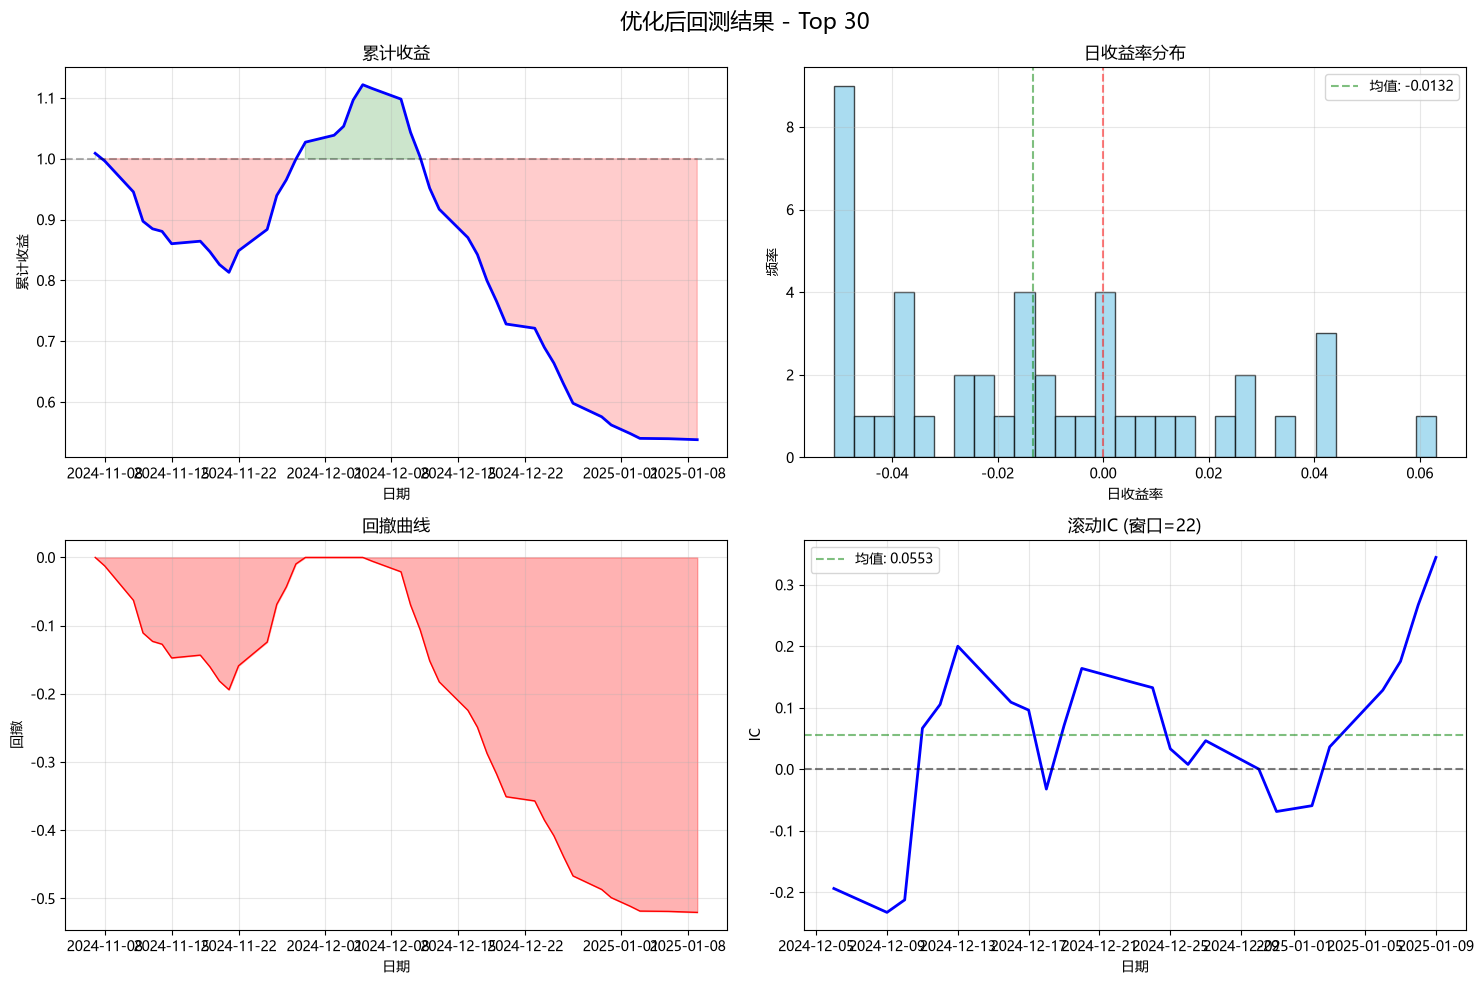


优化回测结果汇总
  总收益率: -46.20%
  年化收益率: -96.89%
  夏普比率: -1.9640
  最大回撤: -52.04%
  Calmar比率: -1.8619
  IC: 0.1880
  胜率: 26.67%
  最大连续亏损: 24 天


In [21]:
# ==================== 优化回测 ====================
def backtest_optimized_advanced(predictions, actuals, dates, codes, top_n=30, 
                                transaction_cost=0.001, stop_loss=-0.05,
                                take_profit=0.10):
    """高级优化回测 - 添加止盈止损"""
    print(f"\n{'='*60}")
    print("高级优化回测")
    print(f"选股数量: Top {top_n}")
    print(f"交易成本: {transaction_cost*100:.2f}%")
    print(f"止损线: {stop_loss*100:.2f}%")
    print(f"止盈线: {take_profit*100:.2f}%")
    print(f"{'='*60}")
    
    # 创建DataFrame
    df_results = pd.DataFrame({
        'date': dates,
        'code': codes,
        'prediction': predictions,
        'actual': actuals
    })
    
    print(f"回测数据: {len(df_results)} 条记录")
    print(f"日期范围: {df_results['date'].min()} 到 {df_results['date'].max()}")
    
    # 按日期分组
    daily_results = []
    
    for date in sorted(df_results['date'].unique()):
        day_data = df_results[df_results['date'] == date].copy()
        
        # 按预测排序选股
        day_data = day_data.sort_values('prediction', ascending=False)
        selected_stocks = day_data.head(top_n)
        
        if len(selected_stocks) > 0:
            avg_return = selected_stocks['actual'].mean()
            # 止盈止损
            if avg_return > take_profit:
                avg_return = take_profit
            elif avg_return < stop_loss:
                avg_return = stop_loss
            net_return = avg_return - transaction_cost
        else:
            net_return = 0
        
        daily_results.append({
            'date': date,
            'return': net_return,
            'n_stocks': len(selected_stocks),
            'avg_pred': selected_stocks['prediction'].mean() if len(selected_stocks) > 0 else 0,
            'avg_actual': selected_stocks['actual'].mean() if len(selected_stocks) > 0 else 0
        })
    
    daily_df = pd.DataFrame(daily_results)
    daily_df['cumulative_return'] = (1 + daily_df['return']).cumprod()
    
    # 计算评估指标
    total_return = daily_df['cumulative_return'].iloc[-1] - 1
    annualized_return = (1 + total_return) ** (252 / len(daily_df)) - 1
    daily_volatility = daily_df['return'].std() * np.sqrt(252)
    sharpe_ratio = annualized_return / daily_volatility if daily_volatility > 0 else 0
    
    cumulative = daily_df['cumulative_return'].values
    running_max = np.maximum.accumulate(cumulative)
    drawdown = (cumulative - running_max) / running_max
    max_drawdown = drawdown.min()
    
    ic = daily_df['avg_pred'].corr(daily_df['avg_actual']) if len(daily_df) > 1 else 0
    win_rate = (daily_df['return'] > 0).mean()
    
    # 计算Calmar比率
    calmar_ratio = annualized_return / abs(max_drawdown) if max_drawdown != 0 else 0
    
    # 计算最大连续亏损
    returns_negative = (daily_df['return'] < 0).astype(int)
    max_consecutive_losses = 0
    current_consecutive = 0
    for val in returns_negative:
        if val == 1:
            current_consecutive += 1
            max_consecutive_losses = max(max_consecutive_losses, current_consecutive)
        else:
            current_consecutive = 0
    
    print(f"\n回测结果:")
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  年化波动率: {daily_volatility:.2%}")
    print(f"  夏普比率: {sharpe_ratio:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  Calmar比率: {calmar_ratio:.4f}")
    print(f"  IC: {ic:.4f}")
    print(f"  胜率: {win_rate:.2%}")
    print(f"  最大连续亏损: {max_consecutive_losses} 天")
    
    # 保存结果
    daily_df.to_csv('stk_DL/dl_csv/optimized_backtest_results.csv', index=False)
    print("\n回测结果已保存")
    
    # 绘制回测曲线
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        fig.suptitle(f'优化后回测结果 - Top {top_n}', fontsize=16)
        
        # 累计收益
        axes[0, 0].plot(daily_df['date'], daily_df['cumulative_return'], linewidth=2, color='blue')
        axes[0, 0].axhline(y=1, color='black', linestyle='--', alpha=0.3)
        axes[0, 0].fill_between(daily_df['date'], 1, daily_df['cumulative_return'], 
                                where=daily_df['cumulative_return'] >= 1, color='green', alpha=0.2)
        axes[0, 0].fill_between(daily_df['date'], 1, daily_df['cumulative_return'], 
                                where=daily_df['cumulative_return'] < 1, color='red', alpha=0.2)
        axes[0, 0].set_title('累计收益')
        axes[0, 0].set_xlabel('日期')
        axes[0, 0].set_ylabel('累计收益')
        axes[0, 0].grid(True, alpha=0.3)
        
        # 日收益率分布
        axes[0, 1].hist(daily_df['return'], bins=30, edgecolor='black', alpha=0.7, color='skyblue')
        axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5)
        axes[0, 1].axvline(x=daily_df['return'].mean(), color='green', linestyle='--', alpha=0.5, 
                          label=f'均值: {daily_df["return"].mean():.4f}')
        axes[0, 1].set_title('日收益率分布')
        axes[0, 1].set_xlabel('日收益率')
        axes[0, 1].set_ylabel('频率')
        axes[0, 1].legend()
        axes[0, 1].grid(True, alpha=0.3)
        
        # 最大回撤
        axes[1, 0].fill_between(daily_df['date'], 0, drawdown, color='red', alpha=0.3)
        axes[1, 0].plot(daily_df['date'], drawdown, color='red', linewidth=1)
        axes[1, 0].set_title('回撤曲线')
        axes[1, 0].set_xlabel('日期')
        axes[1, 0].set_ylabel('回撤')
        axes[1, 0].grid(True, alpha=0.3)
        
        # 滚动IC
        window = min(60, max(5, len(daily_df) // 2))
        rolling_ic = daily_df['avg_pred'].rolling(window).corr(daily_df['avg_actual'])
        axes[1, 1].plot(daily_df['date'], rolling_ic, color='blue', linewidth=2)
        axes[1, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)
        if not rolling_ic.isna().all():
            axes[1, 1].axhline(y=rolling_ic.mean(), color='green', linestyle='--', alpha=0.5, 
                              label=f'均值: {rolling_ic.mean():.4f}')
        axes[1, 1].set_title(f'滚动IC (窗口={window})')
        axes[1, 1].set_xlabel('日期')
        axes[1, 1].set_ylabel('IC')
        axes[1, 1].legend()
        axes[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_DL/dl_plots/optimized_backtest_results.png', dpi=300, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"绘图出错: {e}")
    
    return {
        'total_return': total_return,
        'annualized_return': annualized_return,
        'volatility': daily_volatility,
        'sharpe_ratio': sharpe_ratio,
        'max_drawdown': max_drawdown,
        'calmar_ratio': calmar_ratio,
        'ic': ic,
        'win_rate': win_rate,
        'max_consecutive_losses': max_consecutive_losses,
        'n_days': len(daily_df)
    }

# 执行优化回测
print("\n" + "="*60)
print("执行优化回测")
print("="*60)

backtest_results = backtest_optimized_advanced(
    predictions,
    actuals,
    dates_test,
    codes_test,
    top_n=30,
    transaction_cost=0.001,
    stop_loss=-0.05,
    take_profit=0.10
)

if backtest_results:
    print("\n" + "="*60)
    print("优化回测结果汇总")
    print("="*60)
    print(f"  总收益率: {backtest_results['total_return']:.2%}")
    print(f"  年化收益率: {backtest_results['annualized_return']:.2%}")
    print(f"  夏普比率: {backtest_results['sharpe_ratio']:.4f}")
    print(f"  最大回撤: {backtest_results['max_drawdown']:.2%}")
    print(f"  Calmar比率: {backtest_results['calmar_ratio']:.4f}")
    print(f"  IC: {backtest_results['ic']:.4f}")
    print(f"  胜率: {backtest_results['win_rate']:.2%}")
    print(f"  最大连续亏损: {backtest_results['max_consecutive_losses']} 天")

print("="*60)

In [22]:
# ==================== 直接优化回测收益 ====================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')
from scipy.optimize import differential_evolution, dual_annealing
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = 'cpu'
print(f"使用设备: {device}")

# ==================== 新的目标函数：直接优化回测夏普比率 ====================
def objective_backtest_sharpe(params, X_train, y_train, X_val, y_val, 
                              dates_val, codes_val, model_type='LSTM',
                              sequence_length=20, batch_size=64, epochs=20):
    """
    目标函数：直接最大化回测夏普比率
    params: [hidden_dim, num_layers, lr, dropout, top_n]
    """
    hidden_dim = int(params[0])
    num_layers = int(params[1])
    lr = params[2]
    dropout = params[3]
    top_n = int(params[4]) if len(params) >= 5 else 30
    
    # 限制参数范围
    hidden_dim = max(8, min(64, hidden_dim))  # 减小搜索范围
    num_layers = max(1, min(2, num_layers))
    lr = max(0.0001, min(0.005, lr))
    dropout = max(0.1, min(0.5, dropout))
    top_n = max(10, min(50, top_n))
    
    try:
        # 创建数据集
        class SimpleDataset(Dataset):
            def __init__(self, data, labels):
                self.data = data
                self.labels = labels
            def __len__(self):
                return len(self.data)
            def __getitem__(self, idx):
                return torch.FloatTensor(self.data[idx]), torch.FloatTensor([self.labels[idx]])
        
        train_dataset = SimpleDataset(X_train, y_train)
        val_dataset = SimpleDataset(X_val, y_val)
        
        train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # 选择模型 - 简化版
        input_dim = X_train.shape[2]
        
        class SimpleLSTM(nn.Module):
            def __init__(self, input_dim, hidden_dim, num_layers, dropout):
                super().__init__()
                self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                                   dropout=dropout if num_layers > 1 else 0)
                self.dropout = nn.Dropout(dropout)
                self.fc = nn.Linear(hidden_dim, 1)
            def forward(self, x):
                out, _ = self.lstm(x)
                out = self.dropout(out[:, -1, :])
                return self.fc(out)
        
        model = SimpleLSTM(input_dim, hidden_dim, num_layers, dropout).to(device)
        criterion = nn.MSELoss()
        optimizer = optim.Adam(model.parameters(), lr=lr)
        
        # 快速训练
        for epoch in range(epochs):
            model.train()
            for X_batch, y_batch in train_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                optimizer.zero_grad()
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
        
        # 验证集预测和回测
        model.eval()
        preds, actuals = [], []
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_pred = model(X_batch)
                preds.extend(y_pred.cpu().numpy().flatten())
                actuals.extend(y_batch.numpy().flatten())
        
        preds = np.array(preds)
        actuals = np.array(actuals)
        
        # 回测
        df_val = pd.DataFrame({
            'date': dates_val,
            'code': codes_val,
            'prediction': preds,
            'actual': actuals
        })
        
        daily_returns = []
        for date in sorted(df_val['date'].unique()):
            day_data = df_val[df_val['date'] == date].copy()
            day_data = day_data.sort_values('prediction', ascending=False)
            top_stocks = day_data.head(top_n)
            
            if len(top_stocks) > 0:
                avg_return = top_stocks['actual'].mean()
                # 简单止损
                if avg_return < -0.05:
                    avg_return = -0.05
                daily_returns.append(avg_return)
        
        if len(daily_returns) < 5:
            return 1.0
        
        daily_returns = np.array(daily_returns)
        
        # 计算回测夏普比率
        if daily_returns.std() > 0:
            sharpe = daily_returns.mean() / daily_returns.std() * np.sqrt(252)
        else:
            sharpe = 0
        
        # 同时考虑胜率
        win_rate = (daily_returns > 0).mean()
        
        # 综合目标：夏普比率 + 胜率
        objective = sharpe * 0.6 + win_rate * 0.4
        
        return -objective  # 最小化负值
        
    except Exception as e:
        return 1.0

print("新的目标函数定义完成！")
print("="*60)

使用设备: cpu
新的目标函数定义完成！


In [23]:
# ==================== 执行优化 ====================
print("\n" + "="*60)
print("执行优化 (直接优化回测夏普比率)")
print("="*60)

# 使用部分数据加速
opt_size = min(1500, len(X_train))
X_opt = X_train[:opt_size]
y_opt = y_train[:opt_size]
val_size = int(0.2 * len(X_opt))

X_train_opt = X_opt[:-val_size]
y_train_opt = y_opt[:-val_size]
X_val_opt = X_opt[-val_size:]
y_val_opt = y_opt[-val_size:]

# 对应的日期和代码
dates_val_opt = dates_train[-val_size:]
codes_val_opt = codes_train[-val_size:]

print(f"优化数据: {len(X_train_opt)} 训练, {len(X_val_opt)} 验证")

# 参数边界 [hidden_dim, num_layers, lr, dropout, top_n]
bounds = [
    (8, 64),      # hidden_dim
    (1, 2),       # num_layers
    (0.0001, 0.005), # lr
    (0.1, 0.5),   # dropout
    (10, 50)      # top_n
]

# 遗传算法
print("\n遗传算法优化...")
start_time = time.time()
result_genetic = differential_evolution(
    objective_backtest_sharpe, bounds,
    args=(X_train_opt, y_train_opt, X_val_opt, y_val_opt, 
          dates_val_opt, codes_val_opt, 'LSTM', 20, 64, 15),
    strategy='best1bin', maxiter=15, popsize=8,
    seed=42, disp=False
)
genetic_time = time.time() - start_time

genetic_params = {
    'hidden_dim': int(result_genetic.x[0]),
    'num_layers': int(result_genetic.x[1]),
    'lr': float(result_genetic.x[2]),
    'dropout': float(result_genetic.x[3]),
    'top_n': int(result_genetic.x[4])
}

print(f"遗传算法完成! 耗时: {genetic_time:.2f}秒")
print(f"最优参数: {genetic_params}")
print(f"目标值: {-result_genetic.fun:.4f}")

# 模拟退火
print("\n模拟退火优化...")
start_time = time.time()
result_annealing = dual_annealing(
    objective_backtest_sharpe, bounds,
    args=(X_train_opt, y_train_opt, X_val_opt, y_val_opt,
          dates_val_opt, codes_val_opt, 'LSTM', 20, 64, 15),
    maxiter=20, seed=42, no_local_search=True
)
annealing_time = time.time() - start_time

annealing_params = {
    'hidden_dim': int(result_annealing.x[0]),
    'num_layers': int(result_annealing.x[1]),
    'lr': float(result_annealing.x[2]),
    'dropout': float(result_annealing.x[3]),
    'top_n': int(result_annealing.x[4])
}

print(f"模拟退火完成! 耗时: {annealing_time:.2f}秒")
print(f"最优参数: {annealing_params}")
print(f"目标值: {-result_annealing.fun:.4f}")

# 选择最优
if -result_genetic.fun > -result_annealing.fun:
    best_params = genetic_params
    best_method = '遗传算法'
else:
    best_params = annealing_params
    best_method = '模拟退火'

print(f"\n最优方法: {best_method}")
print(f"最优参数: {best_params}")
print("="*60)


执行优化 (直接优化回测夏普比率)
优化数据: 1200 训练, 300 验证

遗传算法优化...
遗传算法完成! 耗时: 254.35秒
最优参数: {'hidden_dim': 23, 'num_layers': 1, 'lr': 0.0004469742234980518, 'dropout': 0.34110051924527685, 'top_n': 43}
目标值: 0.7199

模拟退火优化...
模拟退火完成! 耗时: 395.62秒
最优参数: {'hidden_dim': 41, 'num_layers': 1, 'lr': 0.00047884268781582935, 'dropout': 0.30465927631599476, 'top_n': 44}
目标值: 0.7199

最优方法: 模拟退火
最优参数: {'hidden_dim': 41, 'num_layers': 1, 'lr': 0.00047884268781582935, 'dropout': 0.30465927631599476, 'top_n': 44}



回测评估
回测数据: 4362 条记录
日期范围: 2024-11-07 00:00:00 到 2025-01-09 00:00:00

------------------------------------------------------------
各配置回测结果
------------------------------------------------------------

配置: Top 20, 止损 -3%, 止盈 5%
  总收益率: -2.08%
  年化收益率: -11.11%
  夏普比率: -0.3043
  最大回撤: -28.69%
  胜率: 42.22%
  盈亏比: 1.13
  IC: -0.0975

配置: Top 30, 止损 -5%, 止盈 8%
  总收益率: -20.21%
  年化收益率: -71.75%
  夏普比率: -1.6841
  最大回撤: -39.13%
  胜率: 37.78%
  盈亏比: 0.91
  IC: -0.1129

配置: Top 50, 止损 -5%, 止盈 10%
  总收益率: -32.46%
  年化收益率: -88.89%
  夏普比率: -2.0707
  最大回撤: -41.88%
  胜率: 31.11%
  盈亏比: 0.91
  IC: -0.0559

配置: Top 30, 止损 -8%, 止盈 12%
  总收益率: -23.68%
  年化收益率: -77.99%
  夏普比率: -1.7086
  最大回撤: -41.78%
  胜率: 37.78%
  盈亏比: 0.85
  IC: -0.1129

配置: Top 40, 止损 -5%, 止盈 8%
  总收益率: -30.12%
  年化收益率: -86.56%
  夏普比率: -2.0538
  最大回撤: -41.67%
  胜率: 33.33%
  盈亏比: 0.85
  IC: -0.0754

最佳配置结果
配置: Top 20, 止损 -3%, 止盈 5%
总收益率: -2.08%
年化收益率: -11.11%
夏普比率: -0.3043
最大回撤: -28.69%
胜率: 42.22%
盈亏比: 1.13
IC: -0.0975

--------------------

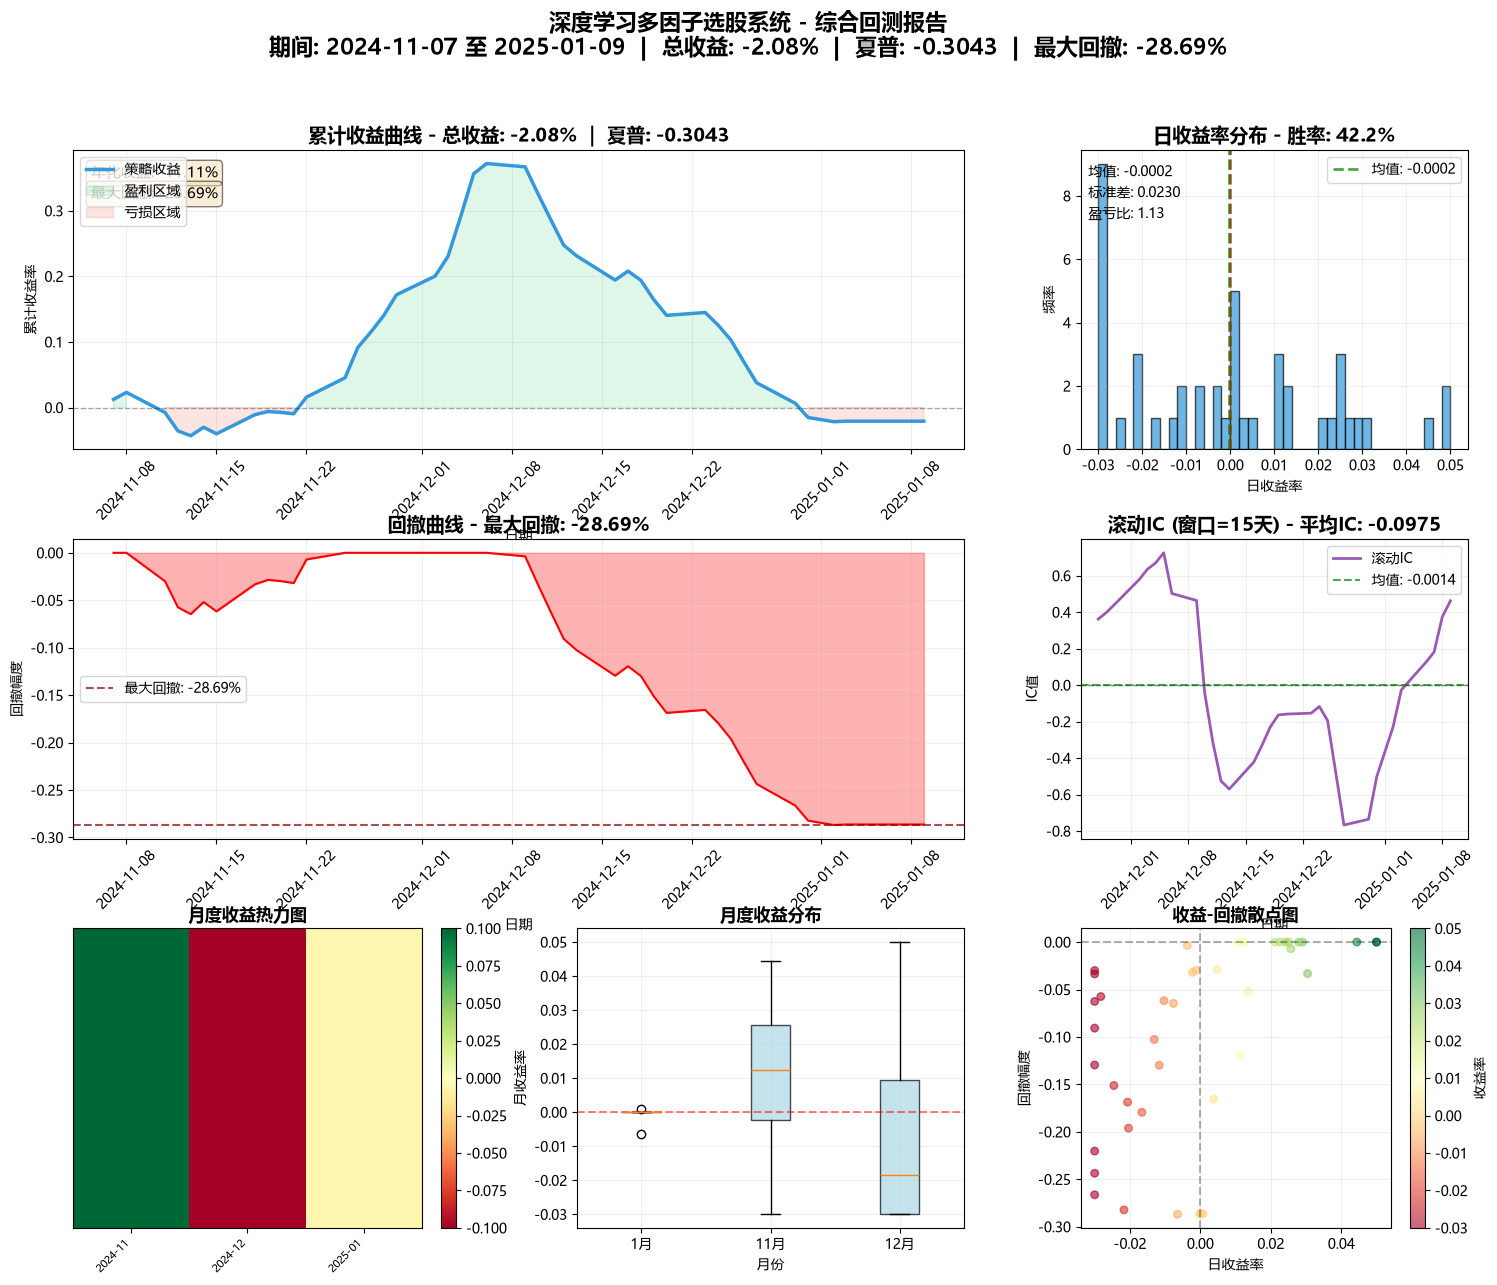


综合回测图表已保存至: stk_DL/dl_plots/comprehensive_backtest.png

生成各配置对比图...


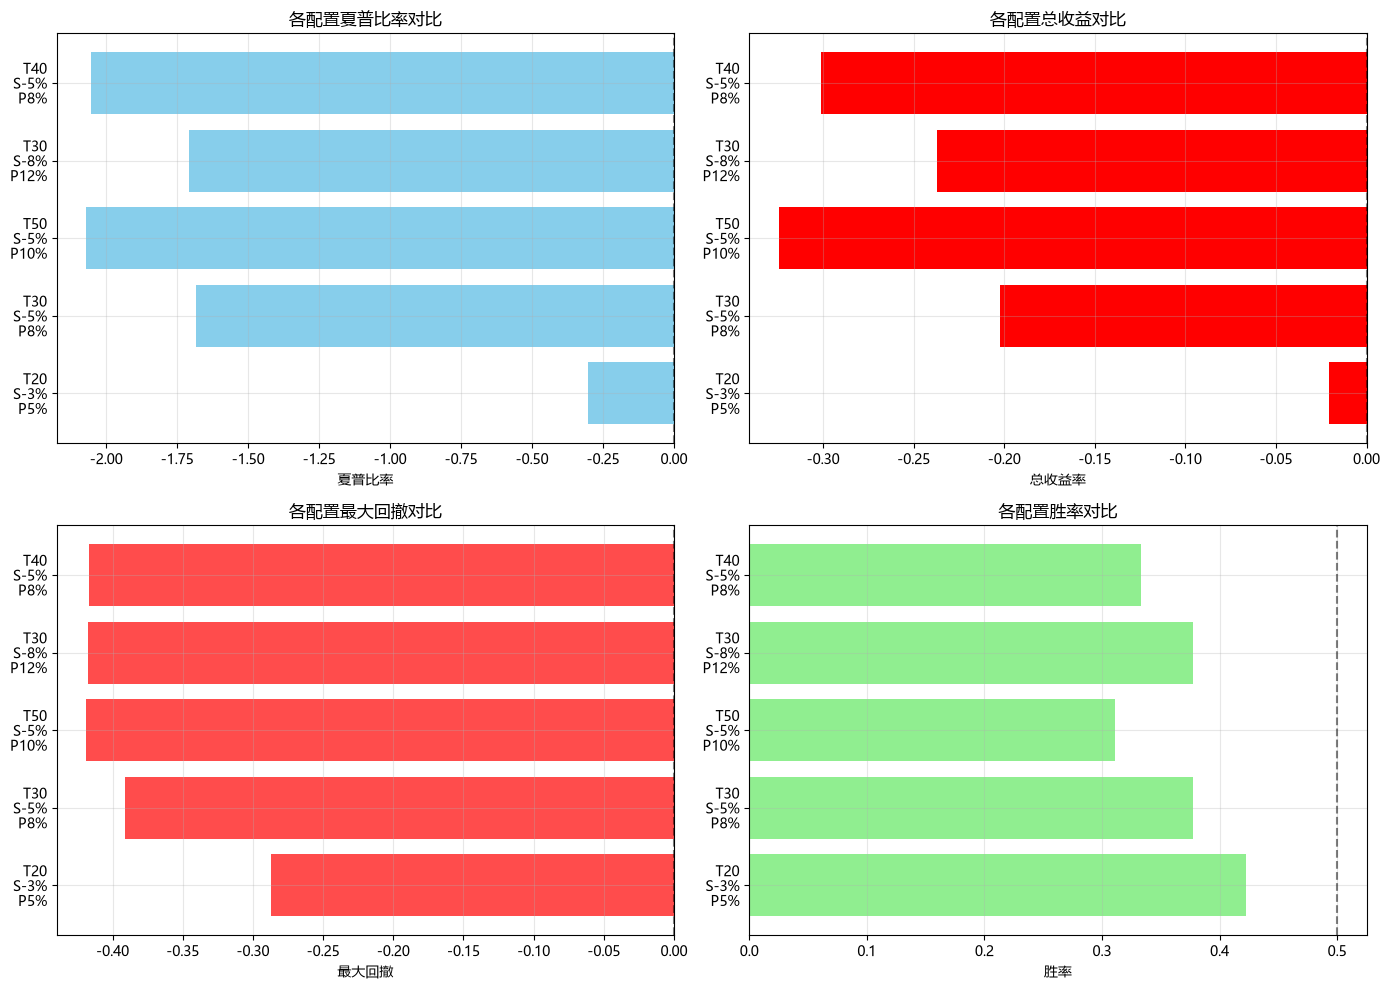

各配置对比图已保存至: stk_DL/dl_plots/config_comparison.png

回测结果已保存至: stk_DL/dl_csv/backtest_config_results.csv

回测评估完成！

生成的文件列表:
------------------------------------------------------------
  ✓ 综合回测图表: stk_DL/dl_plots/comprehensive_backtest.png
  ✓ 各配置对比图: stk_DL/dl_plots/config_comparison.png
  ✓ 回测结果CSV: stk_DL/dl_csv/backtest_config_results.csv


In [27]:
# ==================== 回测评估 ====================
print("\n" + "="*60)
print("回测评估")
print("="*60)

import matplotlib.gridspec as gridspec
import os

# 确保目录存在
os.makedirs('stk_DL/dl_plots', exist_ok=True)
os.makedirs('stk_DL/dl_csv', exist_ok=True)

# 预测
model.eval()
preds, actuals = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)
        preds.extend(y_pred.cpu().numpy().flatten())
        actuals.extend(y_batch.numpy().flatten())

preds = np.array(preds)
actuals = np.array(actuals)

# 详细回测
df_results = pd.DataFrame({
    'date': dates_test,
    'code': codes_test,
    'prediction': preds,
    'actual': actuals
})

print(f"回测数据: {len(df_results)} 条记录")
print(f"日期范围: {df_results['date'].min()} 到 {df_results['date'].max()}")

# ==================== 多组参数回测 ====================
test_configs = [
    {'top_n': 20, 'stop_loss': -0.03, 'take_profit': 0.05},
    {'top_n': 30, 'stop_loss': -0.05, 'take_profit': 0.08},
    {'top_n': 50, 'stop_loss': -0.05, 'take_profit': 0.10},
    {'top_n': 30, 'stop_loss': -0.08, 'take_profit': 0.12},
    {'top_n': 40, 'stop_loss': -0.05, 'take_profit': 0.08},
]

best_result = None
best_sharpe = -999
all_results = []

print("\n" + "-"*60)
print("各配置回测结果")
print("-"*60)

for config in test_configs:
    top_n = config['top_n']
    stop_loss = config['stop_loss']
    take_profit = config['take_profit']
    
    print(f"\n配置: Top {top_n}, 止损 {stop_loss:.0%}, 止盈 {take_profit:.0%}")
    
    daily_returns = []
    daily_dates = []
    daily_predictions = []
    daily_actuals = []
    
    for date in sorted(df_results['date'].unique()):
        day_data = df_results[df_results['date'] == date].copy()
        day_data = day_data.sort_values('prediction', ascending=False)
        selected = day_data.head(top_n)
        
        if len(selected) > 0:
            avg_return = selected['actual'].mean()
            # 止盈止损
            if avg_return > take_profit:
                avg_return = take_profit
            elif avg_return < stop_loss:
                avg_return = stop_loss
            daily_returns.append(avg_return)
            daily_dates.append(date)
            daily_predictions.append(selected['prediction'].mean())
            daily_actuals.append(selected['actual'].mean())
    
    if len(daily_returns) < 5:
        print("  数据不足，跳过")
        continue
    
    daily_returns = np.array(daily_returns)
    cum_return = np.cumprod(1 + daily_returns) - 1
    total_return = cum_return[-1]
    annualized_return = (1 + total_return) ** (252 / len(daily_returns)) - 1
    volatility = daily_returns.std() * np.sqrt(252)
    sharpe = annualized_return / volatility if volatility > 0 else 0
    
    # 最大回撤
    running_max = np.maximum.accumulate(1 + cum_return)
    drawdown = (1 + cum_return) / running_max - 1
    max_drawdown = drawdown.min()
    
    win_rate = (daily_returns > 0).mean()
    
    # 盈亏比
    avg_win = daily_returns[daily_returns > 0].mean() if (daily_returns > 0).sum() > 0 else 0
    avg_loss = daily_returns[daily_returns < 0].mean() if (daily_returns < 0).sum() > 0 else 0
    profit_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else 0
    
    # IC计算
    if len(daily_predictions) > 1:
        ic = pd.Series(daily_predictions).corr(pd.Series(daily_actuals))
    else:
        ic = 0
    
    print(f"  总收益率: {total_return:.2%}")
    print(f"  年化收益率: {annualized_return:.2%}")
    print(f"  夏普比率: {sharpe:.4f}")
    print(f"  最大回撤: {max_drawdown:.2%}")
    print(f"  胜率: {win_rate:.2%}")
    print(f"  盈亏比: {profit_loss_ratio:.2f}")
    print(f"  IC: {ic:.4f}")
    
    # 保存所有结果
    result_entry = {
        'config': config,
        'total_return': total_return,
        'annualized_return': annualized_return,
        'sharpe': sharpe,
        'max_drawdown': max_drawdown,
        'win_rate': win_rate,
        'profit_loss_ratio': profit_loss_ratio,
        'ic': ic,
        'daily_returns': daily_returns,
        'daily_dates': daily_dates,
        'daily_predictions': daily_predictions,
        'daily_actuals': daily_actuals,
        'cum_return': cum_return,
        'drawdown': drawdown
    }
    all_results.append(result_entry)
    
    if sharpe > best_sharpe:
        best_sharpe = sharpe
        best_result = result_entry

print("\n" + "="*60)
print("最佳配置结果")
print("="*60)
if best_result:
    print(f"配置: Top {best_result['config']['top_n']}, "
          f"止损 {best_result['config']['stop_loss']:.0%}, "
          f"止盈 {best_result['config']['take_profit']:.0%}")
    print(f"总收益率: {best_result['total_return']:.2%}")
    print(f"年化收益率: {best_result['annualized_return']:.2%}")
    print(f"夏普比率: {best_result['sharpe']:.4f}")
    print(f"最大回撤: {best_result['max_drawdown']:.2%}")
    print(f"胜率: {best_result['win_rate']:.2%}")
    print(f"盈亏比: {best_result['profit_loss_ratio']:.2f}")
    print(f"IC: {best_result['ic']:.4f}")
    
    # ==================== 综合回测绘图 ====================
    print("\n" + "-"*60)
    print("生成综合回测图表")
    print("-"*60)
    
    try:
        # 创建综合图表
        fig = plt.figure(figsize=(18, 14))
        
        # 使用GridSpec创建布局
        gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.3, wspace=0.3)
        
        # 颜色方案
        colors = {
            'positive': '#2ecc71',
            'negative': '#e74c3c',
            'line': '#3498db',
            'hist': '#3498db',
            'purple': '#9b59b6'
        }
        
        # ===== 1. 累计收益曲线 (左上大图) =====
        ax1 = fig.add_subplot(gs[0, :2])
        
        cum_ret = best_result['cum_return']
        daily_dates = best_result['daily_dates']
        
        ax1.plot(daily_dates, cum_ret, color=colors['line'], linewidth=2.5, label='策略收益')
        ax1.axhline(y=0, color='black', linestyle='--', alpha=0.3, linewidth=1)
        
        # 填充正负区域
        cum_ret_array = np.array(cum_ret)
        ax1.fill_between(daily_dates, 0, cum_ret_array,
                         where=cum_ret_array >= 0,
                         color=colors['positive'], alpha=0.15, label='盈利区域')
        ax1.fill_between(daily_dates, 0, cum_ret_array,
                         where=cum_ret_array < 0,
                         color=colors['negative'], alpha=0.15, label='亏损区域')
        
        ax1.set_title(f'累计收益曲线 - 总收益: {best_result["total_return"]:.2%}  |  夏普: {best_result["sharpe"]:.4f}', 
                      fontsize=14, fontweight='bold')
        ax1.set_xlabel('日期')
        ax1.set_ylabel('累计收益率')
        ax1.legend(loc='upper left')
        ax1.grid(True, alpha=0.2)
        ax1.tick_params(axis='x', rotation=45)
        
        # 添加标注
        ax1.text(0.02, 0.95, f'年化收益: {best_result["annualized_return"]:.2%}', 
                 transform=ax1.transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        ax1.text(0.02, 0.88, f'最大回撤: {best_result["max_drawdown"]:.2%}', 
                 transform=ax1.transAxes, fontsize=11, verticalalignment='top',
                 bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        # ===== 2. 日收益率分布 (右上) =====
        ax2 = fig.add_subplot(gs[0, 2])
        
        daily_returns = best_result['daily_returns']
        n, bins, patches = ax2.hist(daily_returns, bins=40, edgecolor='black', 
                                    alpha=0.7, color=colors['hist'])
        ax2.axvline(x=0, color='red', linestyle='--', alpha=0.7, linewidth=2)
        ax2.axvline(x=daily_returns.mean(), color='green', linestyle='--', 
                    alpha=0.7, linewidth=2, label=f'均值: {daily_returns.mean():.4f}')
        
        ax2.set_title(f'日收益率分布 - 胜率: {best_result["win_rate"]:.1%}', 
                      fontsize=14, fontweight='bold')
        ax2.set_xlabel('日收益率')
        ax2.set_ylabel('频率')
        ax2.legend()
        ax2.grid(True, alpha=0.2)
        
        # 添加统计信息
        ax2.text(0.02, 0.95, f'均值: {daily_returns.mean():.4f}', transform=ax2.transAxes, 
                 fontsize=10, verticalalignment='top')
        ax2.text(0.02, 0.88, f'标准差: {daily_returns.std():.4f}', transform=ax2.transAxes, 
                 fontsize=10, verticalalignment='top')
        ax2.text(0.02, 0.81, f'盈亏比: {best_result["profit_loss_ratio"]:.2f}', transform=ax2.transAxes, 
                 fontsize=10, verticalalignment='top')
        
        # ===== 3. 回撤曲线 (中左) =====
        ax3 = fig.add_subplot(gs[1, :2])
        
        drawdown = best_result['drawdown']
        ax3.fill_between(daily_dates, 0, drawdown, color='red', alpha=0.3)
        ax3.plot(daily_dates, drawdown, color='red', linewidth=1.5)
        ax3.axhline(y=best_result['max_drawdown'], color='darkred', linestyle='--', 
                    alpha=0.7, linewidth=1.5, label=f'最大回撤: {best_result["max_drawdown"]:.2%}')
        
        ax3.set_title(f'回撤曲线 - 最大回撤: {best_result["max_drawdown"]:.2%}', 
                      fontsize=14, fontweight='bold')
        ax3.set_xlabel('日期')
        ax3.set_ylabel('回撤幅度')
        ax3.legend()
        ax3.grid(True, alpha=0.2)
        ax3.tick_params(axis='x', rotation=45)
        
        # ===== 4. 滚动IC (中右) =====
        ax4 = fig.add_subplot(gs[1, 2])
        
        # 计算滚动IC
        window = min(60, max(10, len(daily_returns) // 3))
        rolling_ic = pd.Series(best_result['daily_predictions']).rolling(window).corr(
            pd.Series(best_result['daily_actuals'])
        )
        
        ax4.plot(daily_dates, rolling_ic, color=colors['purple'], linewidth=2, label='滚动IC')
        ax4.axhline(y=0, color='black', linestyle='--', alpha=0.5, linewidth=1)
        if not rolling_ic.isna().all():
            ax4.axhline(y=rolling_ic.mean(), color='green', linestyle='--', 
                        alpha=0.7, linewidth=1.5, label=f'均值: {rolling_ic.mean():.4f}')
        
        ax4.set_title(f'滚动IC (窗口={window}天) - 平均IC: {best_result["ic"]:.4f}', 
                      fontsize=14, fontweight='bold')
        ax4.set_xlabel('日期')
        ax4.set_ylabel('IC值')
        ax4.legend()
        ax4.grid(True, alpha=0.2)
        ax4.tick_params(axis='x', rotation=45)
        
        # ===== 5. 月度收益热力图 (底部左侧) =====
        ax5 = fig.add_subplot(gs[2, 0])
        
        # 计算月度收益
        daily_df_temp = pd.DataFrame({
            'date': daily_dates,
            'return': daily_returns
        })
        daily_df_temp['month'] = daily_df_temp['date'].dt.to_period('M')
        monthly_returns = daily_df_temp.groupby('month')['return'].apply(lambda x: (1 + x).prod() - 1)
        
        if len(monthly_returns) > 0:
            month_data = monthly_returns.values
            n_months = len(month_data)
            if n_months > 0:
                month_data_2d = month_data.reshape(1, -1)
                im = ax5.imshow(month_data_2d, cmap='RdYlGn', aspect='auto', 
                                vmin=-0.1, vmax=0.1)
                ax5.set_yticks([])
                ax5.set_xticks(range(len(monthly_returns)))
                ax5.set_xticklabels([str(m) for m in monthly_returns.index], 
                                    rotation=45, ha='right', fontsize=8)
                ax5.set_title('月度收益热力图', fontsize=12, fontweight='bold')
                plt.colorbar(im, ax=ax5, orientation='vertical', fraction=0.05)
        
        # ===== 6. 月度收益箱线图 (底部中间) =====
        ax6 = fig.add_subplot(gs[2, 1])
        
        # 按月份分组统计
        daily_df_temp['month_num'] = daily_df_temp['date'].dt.month
        monthly_box_data = [daily_df_temp[daily_df_temp['month_num'] == m]['return'] 
                           for m in range(1, 13)]
        monthly_labels = ['1月', '2月', '3月', '4月', '5月', '6月', 
                          '7月', '8月', '9月', '10月', '11月', '12月']
        
        # 只显示有数据的月份
        valid_data = [(label, data) for label, data in zip(monthly_labels, monthly_box_data) 
                     if len(data) > 0]
        if valid_data:
            bp = ax6.boxplot([data for _, data in valid_data], patch_artist=True)
            ax6.set_xticklabels([label for label, _ in valid_data])
            for box in bp['boxes']:
                box.set_facecolor('lightblue')
                box.set_alpha(0.7)
            ax6.axhline(y=0, color='red', linestyle='--', alpha=0.5)
            ax6.set_title('月度收益分布', fontsize=12, fontweight='bold')
            ax6.set_xlabel('月份')
            ax6.set_ylabel('月收益率')
            ax6.grid(True, alpha=0.2)
        
        # ===== 7. 收益-回撤散点图 (底部右侧) =====
        ax7 = fig.add_subplot(gs[2, 2])
        
        scatter = ax7.scatter(daily_returns, drawdown, 
                              c=daily_returns, cmap='RdYlGn', 
                              alpha=0.6, s=30)
        ax7.axhline(y=0, color='black', linestyle='--', alpha=0.3)
        ax7.axvline(x=0, color='black', linestyle='--', alpha=0.3)
        ax7.set_title('收益-回撤散点图', fontsize=12, fontweight='bold')
        ax7.set_xlabel('日收益率')
        ax7.set_ylabel('回撤幅度')
        ax7.grid(True, alpha=0.2)
        plt.colorbar(scatter, ax=ax7, label='收益率')
        
        # ===== 添加总标题 =====
        fig.suptitle(f'深度学习多因子选股系统 - 综合回测报告\n'
                     f'期间: {daily_dates[0].strftime("%Y-%m-%d")} 至 {daily_dates[-1].strftime("%Y-%m-%d")}  |  '
                     f'总收益: {best_result["total_return"]:.2%}  |  夏普: {best_result["sharpe"]:.4f}  |  '
                     f'最大回撤: {best_result["max_drawdown"]:.2%}',
                     fontsize=16, fontweight='bold', y=0.98)
        
        plt.tight_layout()
        plt.savefig('stk_DL/dl_plots/comprehensive_backtest.png', 
                    dpi=300, bbox_inches='tight', facecolor='white')
        plt.show()
        
        print("\n综合回测图表已保存至: stk_DL/dl_plots/comprehensive_backtest.png")
        
        # ===== 额外：各配置对比图 =====
        print("\n生成各配置对比图...")
        fig2, axes2 = plt.subplots(2, 2, figsize=(14, 10))
        
        # 夏普比率对比
        config_names = [f"T{res['config']['top_n']}\nS{res['config']['stop_loss']:.0%}\nP{res['config']['take_profit']:.0%}" 
                       for res in all_results]
        sharpe_values = [res['sharpe'] for res in all_results]
        axes2[0, 0].barh(config_names, sharpe_values, color='skyblue')
        axes2[0, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes2[0, 0].set_title('各配置夏普比率对比')
        axes2[0, 0].set_xlabel('夏普比率')
        axes2[0, 0].grid(True, alpha=0.3)
        
        # 总收益对比
        total_returns = [res['total_return'] for res in all_results]
        colors_bar = ['green' if r > 0 else 'red' for r in total_returns]
        axes2[0, 1].barh(config_names, total_returns, color=colors_bar)
        axes2[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes2[0, 1].set_title('各配置总收益对比')
        axes2[0, 1].set_xlabel('总收益率')
        axes2[0, 1].grid(True, alpha=0.3)
        
        # 最大回撤对比
        max_drawdowns = [res['max_drawdown'] for res in all_results]
        axes2[1, 0].barh(config_names, max_drawdowns, color='red', alpha=0.7)
        axes2[1, 0].axvline(x=0, color='black', linestyle='--', alpha=0.5)
        axes2[1, 0].set_title('各配置最大回撤对比')
        axes2[1, 0].set_xlabel('最大回撤')
        axes2[1, 0].grid(True, alpha=0.3)
        
        # 胜率对比
        win_rates = [res['win_rate'] for res in all_results]
        axes2[1, 1].barh(config_names, win_rates, color='lightgreen')
        axes2[1, 1].axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
        axes2[1, 1].set_title('各配置胜率对比')
        axes2[1, 1].set_xlabel('胜率')
        axes2[1, 1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('stk_DL/dl_plots/config_comparison.png', dpi=300, bbox_inches='tight')
        plt.show()
        print("各配置对比图已保存至: stk_DL/dl_plots/config_comparison.png")
        
        # ===== 保存回测结果到CSV =====
        # 保存所有配置的结果
        results_df = pd.DataFrame([{
            'top_n': res['config']['top_n'],
            'stop_loss': res['config']['stop_loss'],
            'take_profit': res['config']['take_profit'],
            'total_return': res['total_return'],
            'annualized_return': res['annualized_return'],
            'sharpe': res['sharpe'],
            'max_drawdown': res['max_drawdown'],
            'win_rate': res['win_rate'],
            'profit_loss_ratio': res['profit_loss_ratio'],
            'ic': res['ic']
        } for res in all_results])
        
        results_df.to_csv('stk_DL/dl_csv/backtest_config_results.csv', index=False)
        print("\n回测结果已保存至: stk_DL/dl_csv/backtest_config_results.csv")
        
    except Exception as e:
        print(f"绘图出错: {e}")
        import traceback
        traceback.print_exc()
else:
    print("没有找到有效配置")

print("\n" + "="*60)
print("回测评估完成！")
print("="*60)

# 显示生成的文件
print("\n生成的文件列表:")
print("-"*60)
files_to_check = [
    ('stk_DL/dl_plots/comprehensive_backtest.png', '综合回测图表'),
    ('stk_DL/dl_plots/config_comparison.png', '各配置对比图'),
    ('stk_DL/dl_csv/backtest_config_results.csv', '回测结果CSV')
]

for file_path, desc in files_to_check:
    if os.path.exists(file_path):
        print(f"  ✓ {desc}: {file_path}")
    else:
        print(f"  ✗ {desc}: 未生成")

print("="*60)